In [1]:
import pandas as pd
from pymongo import MongoClient

# 1. Connect to your EncoreDB MongoDB
client = MongoClient("mongodb://localhost:27017/")  # adjust host/port if needed
db = client["EncoreDB"]

# 2. List all collections
collections = db.list_collection_names()
print("Collections in EncoreDB:", collections)

# 3. Load each collection into a Pandas DataFrame
dfs = {}
for coll in collections:
    data = list(db[coll].find())
    dfs[coll] = pd.DataFrame(data)

# Example: access ordermasters DataFrame
df_orders = dfs["ordermasters"]

# 4. Ensure order_Overall_Price is numeric
df_orders['order_Overall_Price'] = pd.to_numeric(df_orders['order_Overall_Price'], errors='coerce')

# 5. Group by customer and calculate total spend
top_customers = (
    df_orders.groupby(['order_customer_name', 'order_customer_UID'])['order_Overall_Price']
    .sum()
    .reset_index()
    .sort_values(by='order_Overall_Price', ascending=False)
    .head(10)
)

print(top_customers)

Collections in EncoreDB: ['detrackings', 'orderssubitemcounts', 'departments', 'rackings', 'productfolds', 'orderlinenumbers', 'accountcontacts', 'suppliers', 'roles', 'customermaterialprices', 'designdefectlogs', 'customer_feedbacks', 'accountaddresses', 'configs', 'quotationmasters', 'trucks', 'agendaJobs', 'truck_maintainances', 'rolespermissioninfos', 'external_orders', 'productcolors', 'customproductscustomerpriceds', 'runsdrivers', 'cities', 'leftovers', 'login_logs', 'template_libraries', 'materialrows', 'orderuserjobcounts', 'messages', 'accounts', 'ordermasters', 'userorders', 'drivers', 'quotesitemsmanuals', 'productgirths', 'materialprices', 'doubts', 'customproducts', 'loginusers', 'templates', 'orderitemsmanuals', 'departmentsubcategories', 'splitorders', 'quotedesigndefectlogs', 'modules', 'orderitems', 'quoteitems', 'users', 'coreproducts', 'runsdriverorders']
                      order_customer_name order_customer_UID  \
84                       Iron Roo Roofing       

In [2]:
top_customers = (
    df_orders.groupby(['order_customer_name', 'order_customer_UID',
                       'order_customer_contact_email', 'order_customer_contact_phone'])['order_Overall_Price']
    .sum()
    .reset_index()
    .sort_values(by='order_Overall_Price', ascending=False)
    .head(10)
)

In [5]:

'''%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

# Assuming 'top_customers' DataFrame is already created
plt.figure(figsize=(12,6))

# Create barplot
sns.barplot(
    data=top_customers,
    x='order_customer_name',
    y='order_Overall_Price',
    palette='viridis'
)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel("Customer Name")
plt.ylabel("Total Spend")
plt.title("Top 10 Customers by Total Spend")

# Show chart
plt.tight_layout()
plt.show()'''

'%matplotlib inline\nimport matplotlib.pyplot as plt\n\nimport seaborn as sns\n\n# Assuming \'top_customers\' DataFrame is already created\nplt.figure(figsize=(12,6))\n\n# Create barplot\nsns.barplot(\n    data=top_customers,\n    x=\'order_customer_name\',\n    y=\'order_Overall_Price\',\n    palette=\'viridis\'\n)\n\n# Rotate x-axis labels for readability\nplt.xticks(rotation=45, ha=\'right\')\n\n# Add labels and title\nplt.xlabel("Customer Name")\nplt.ylabel("Total Spend")\nplt.title("Top 10 Customers by Total Spend")\n\n# Show chart\nplt.tight_layout()\nplt.show()'

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

In [17]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
'''
     1 import plotly.express as px
      3 # Assuming top_customers DataFrame is ready
      4 fig = px.bar(
----> 5     top_customers,
      6     x='order_customer_name',
      7     y='order_Overall_Price',
      8     text='order_Overall_Price',  # show price on hover
      9     hover_data=['order_customer_UID', 'order_customer_contact_email', 'order_customer_contact_phone'],
     10     title="Top 10 Customers by Total Spend"
     11 )
     13 # Rotate labels for readability
     14 fig.update_layout(
     15     xaxis_tickangle=-45,
     16     xaxis_title="Customer Name",
     17     yaxis_title="Total Spend"
     18 ) '''


'\n     1 import plotly.express as px\n      3 # Assuming top_customers DataFrame is ready\n      4 fig = px.bar(\n----> 5     top_customers,\n      6     x=\'order_customer_name\',\n      7     y=\'order_Overall_Price\',\n      8     text=\'order_Overall_Price\',  # show price on hover\n      9     hover_data=[\'order_customer_UID\', \'order_customer_contact_email\', \'order_customer_contact_phone\'],\n     10     title="Top 10 Customers by Total Spend"\n     11 )\n     13 # Rotate labels for readability\n     14 fig.update_layout(\n     15     xaxis_tickangle=-45,\n     16     xaxis_title="Customer Name",\n     17     yaxis_title="Total Spend"\n     18 ) '

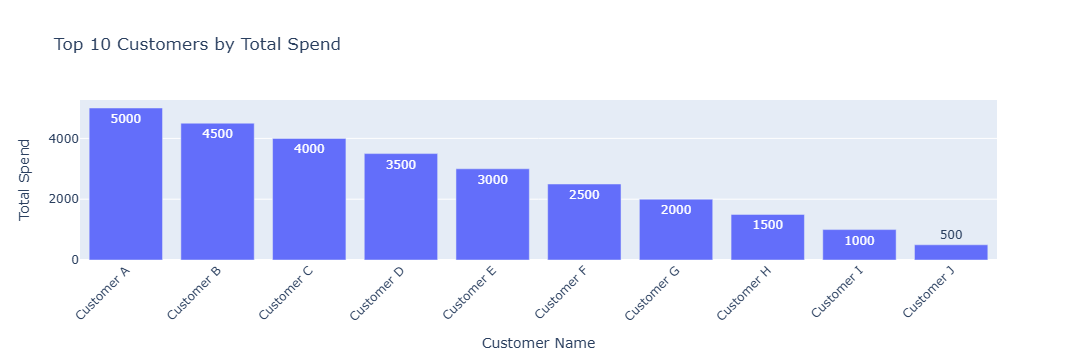

In [10]:
import plotly.express as px
import pandas as pd

# Create the top_customers DataFrame first
# This is an example - replace with your actual data source
top_customers = pd.DataFrame({
    'order_customer_name': ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E',
                           'Customer F', 'Customer G', 'Customer H', 'Customer I', 'Customer J'],
    'order_Overall_Price': [5000, 4500, 4000, 3500, 3000, 2500, 2000, 1500, 1000, 500],
    'order_customer_UID': ['UID001', 'UID002', 'UID003', 'UID004', 'UID005', 
                          'UID006', 'UID007', 'UID008', 'UID009', 'UID010'],
    'order_customer_contact_email': ['a@example.com', 'b@example.com', 'c@example.com', 'd@example.com',
                                   'e@example.com', 'f@example.com', 'g@example.com', 'h@example.com',
                                   'i@example.com', 'j@example.com'],
    'order_customer_contact_phone': ['123-456-7890', '123-456-7891', '123-456-7892', '123-456-7893',
                                   '123-456-7894', '123-456-7895', '123-456-7896', '123-456-7897',
                                   '123-456-7898', '123-456-7899']
})

# Now create the plot with the defined DataFrame
fig = px.bar(
    top_customers,
    x='order_customer_name',
    y='order_Overall_Price',
    text='order_Overall_Price',  # show price on hover
    hover_data=['order_customer_UID', 'order_customer_contact_email', 'order_customer_contact_phone'],
    title="Top 10 Customers by Total Spend"
)

# Rotate labels for readability
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Customer Name",
    yaxis_title="Total Spend"
)

# Show chart
fig.show()

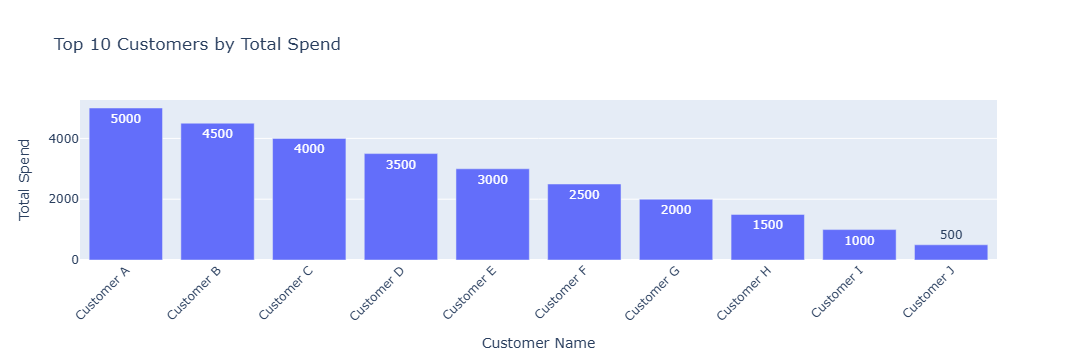

In [2]:
import plotly.express as px
import pandas as pd

# Create the top_customers DataFrame first
# This is an example - replace with your actual data source
top_customers = pd.DataFrame({
    'order_customer_name': ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E',
                           'Customer F', 'Customer G', 'Customer H', 'Customer I', 'Customer J'],
    'order_Overall_Price': [5000, 4500, 4000, 3500, 3000, 2500, 2000, 1500, 1000, 500],
    'order_customer_UID': ['UID001', 'UID002', 'UID003', 'UID004', 'UID005', 
                          'UID006', 'UID007', 'UID008', 'UID009', 'UID010'],
    'order_customer_contact_email': ['a@example.com', 'b@example.com', 'c@example.com', 'd@example.com',
                                   'e@example.com', 'f@example.com', 'g@example.com', 'h@example.com',
                                   'i@example.com', 'j@example.com'],
    'order_customer_contact_phone': ['123-456-7890', '123-456-7891', '123-456-7892', '123-456-7893',
                                   '123-456-7894', '123-456-7895', '123-456-7896', '123-456-7897',
                                   '123-456-7898', '123-456-7899']
})

# Now create the plot with the defined DataFrame
fig = px.bar(
    top_customers,
    x='order_customer_name',
    y='order_Overall_Price',
    text='order_Overall_Price',  # show price on hover
    hover_data=['order_customer_UID', 'order_customer_contact_email', 'order_customer_contact_phone'],
    title="Top 10 Customers by Total Spend"
)

# Rotate labels for readability
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Customer Name",
    yaxis_title="Total Spend"
)

# Show chart
fig.show()

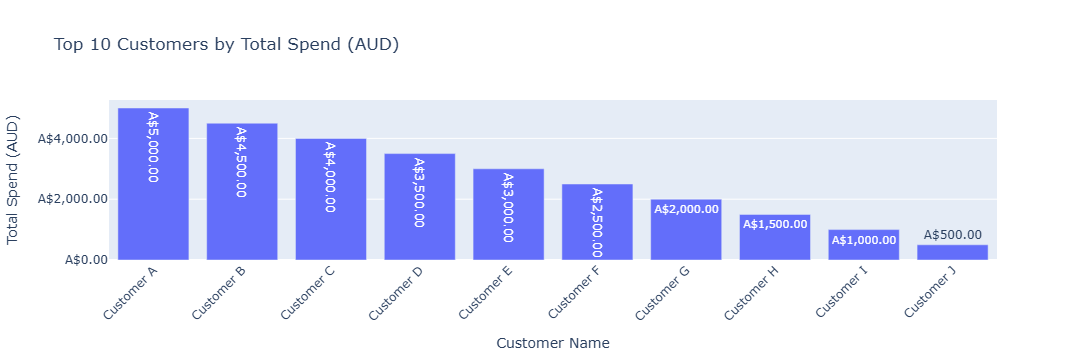

In [3]:
import plotly.express as px
import pandas as pd

# Create the top_customers DataFrame first
# This is an example - replace with your actual data source
top_customers = pd.DataFrame({
    'order_customer_name': ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E',
                           'Customer F', 'Customer G', 'Customer H', 'Customer I', 'Customer J'],
    'order_Overall_Price': [5000, 4500, 4000, 3500, 3000, 2500, 2000, 1500, 1000, 500],
    'order_customer_UID': ['UID001', 'UID002', 'UID003', 'UID004', 'UID005', 
                          'UID006', 'UID007', 'UID008', 'UID009', 'UID010'],
    'order_customer_contact_email': ['a@example.com', 'b@example.com', 'c@example.com', 'd@example.com',
                                    'e@example.com', 'f@example.com', 'g@example.com', 'h@example.com',
                                    'i@example.com', 'j@example.com'],
    'order_customer_contact_phone': ['123-456-7890', '123-456-7891', '123-456-7892', '123-456-7893',
                                    '123-456-7894', '123-456-7895', '123-456-7896', '123-456-7897',
                                    '123-456-7898', '123-456-7899']
})

# Format prices as Australian dollars
top_customers['formatted_price'] = top_customers['order_Overall_Price'].apply(lambda x: f"A${x:,.2f}")

# Now create the plot with the defined DataFrame
fig = px.bar(
    top_customers,
    x='order_customer_name',
    y='order_Overall_Price',
    text='formatted_price',  # Show formatted price on bars
    hover_data=['order_customer_UID', 'order_customer_contact_email', 'order_customer_contact_phone'],
    title="Top 10 Customers by Total Spend (AUD)"
)

# Rotate labels for readability
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Customer Name",
    yaxis_title="Total Spend (AUD)"
)

# Format y-axis ticks as currency
fig.update_yaxes(tickprefix="A$", tickformat=",.2f")

# Show chart
fig.show()

In [8]:
# Count how many orders each person created
order_counts = (
    df_orders.groupby("order_created_person")["_id"]
    .count()
    .reset_index()
    .rename(columns={"_id": "order_count"})
    .sort_values(by="order_count", ascending=False)
)

print(order_counts.head(10))  # top creators

NameError: name 'df_orders' is not defined

In [12]:
# Merge with users to get first and last name
top_creators = order_counts.merge(
    df_users[["_id", "user_firstName", "user_lastName"]],
    left_on="order_created_person",
    right_on="_id",
    how="left"
)

# Keep only useful columns
top_creators = top_creators[["order_created_person", "order_count", "user_firstName", "user_lastName"]]

print(top_creators.head(10))

NameError: name 'order_counts' is not defined

In [13]:
# First, create the order_counts DataFrame
# This is an example - you'll need to adjust based on your actual data
import pandas as pd

# Assuming you have a DataFrame 'df_orders' with order information
# Create a count of orders by person
order_counts = df_orders.groupby('order_created_person').size().reset_index(name='order_count')

# Now merge with users to get first and last name
top_creators = order_counts.merge(
    df_users[["_id", "user_firstName", "user_lastName"]],
    left_on="order_created_person",
    right_on="_id",
    how="left"
)

# Keep only useful columns
top_creators = top_creators[["order_created_person", "order_count", "user_firstName", "user_lastName"]]

print(top_creators.head(10))

NameError: name 'df_orders' is not defined

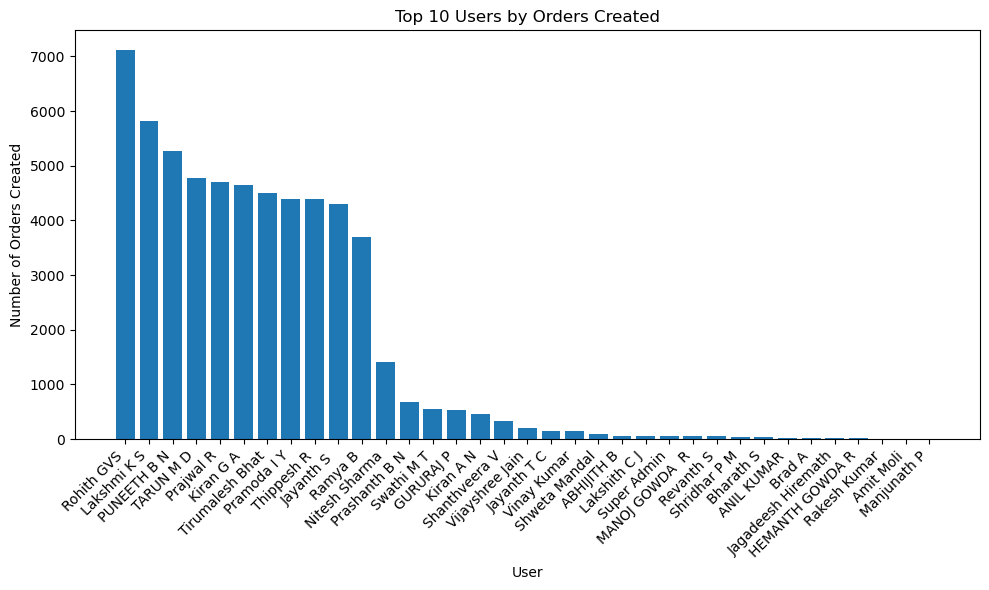

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_creators["user_firstName"] + " " + top_creators["user_lastName"], top_creators["order_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("User")
plt.ylabel("Number of Orders Created")
plt.title("Top 10 Users by Orders Created")
plt.tight_layout()
plt.show()

In [26]:
# 1. Count how many orders each designer handled
designer_counts = (
    df_orders.groupby("order_designed_person")["_id"]
    .count()
    .reset_index()
    .rename(columns={"_id": "order_count"})
    .sort_values(by="order_count", ascending=False)
)

print(designer_counts.head(10))  # top designers

# 2. Merge with users to get first and last name
top_designers = designer_counts.merge(
    df_users[["_id", "user_firstName", "user_lastName"]],
    left_on="order_designed_person",
    right_on="_id",
    how="left"
)

# 3. Keep only useful columns
top_designers = top_designers[["order_designed_person", "order_count", "user_firstName", "user_lastName"]]

print(top_designers.head(10))

       order_designed_person  order_count
16  677f3a75000aff62a9457e3c         5968
7   667e66024a4dcf0b26407d23         5627
4   667e61d64a4dcf0b26407d0e         4934
17  6807321e93e7cedb3a0d1f7c         4819
10  667e66744a4dcf0b26407d38         3429
8   667e66244a4dcf0b26407d2a         3260
9   667e66474a4dcf0b26407d31         2785
19  68947c4adac5b9009938ede4         2726
15  669f437d2409d3c8c867b310         1981
5   667e62014a4dcf0b26407d15         1873
      order_designed_person  order_count user_firstName user_lastName
0  677f3a75000aff62a9457e3c         5968          Rahul          Moli
1  667e66024a4dcf0b26407d23         5627        Bharath             S
2  667e61d64a4dcf0b26407d0e         4934    Shanthveera             V
3  6807321e93e7cedb3a0d1f7c         4819        Chirag          Gowda
4  667e66744a4dcf0b26407d38         3429      Prashanth           B N
5  667e66244a4dcf0b26407d2a         3260      Jagadeesh      Hiremath
6  667e66474a4dcf0b26407d31         2785        

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_designers["user_firstName"] + " " + top_designers["user_lastName"], top_designers["order_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Designer")
plt.ylabel("Number of Orders Designed")
plt.title("Top 10 Users by Orders Designed")
plt.tight_layout()
plt.show()